In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import scipy.stats
from scipy.special import logit, expit
import matplotlib.pyplot as plt

import sys
sys.path.append('../../python/example/berry')
import util

sigma2_n = 90
n_arms = 2
mu_sig_sq = 100.0
mu_0 = -1.34
logit_p1 = logit(0.3)
n = np.full((1, 2), 35)
y = np.array([[4, 8]])
n.shape, y.shape

((1, 2), (1, 2))

In [3]:
sigma2_n = sigma2_n
sigma2_rule = util.log_gauss_rule(sigma2_n, 1e-6, 1e3)
arms = np.arange(n_arms)
cov = np.full((sigma2_n, n_arms, n_arms), mu_sig_sq)
cov[:, arms, arms] += sigma2_rule.pts[:, None]
neg_precQ = -np.linalg.inv(cov)
logprecQdet = 0.5 * np.log(np.linalg.det(-neg_precQ))
log_prior = scipy.stats.invgamma.logpdf(
    sigma2_rule.pts, 0.0005, scale=0.000005
)

In [4]:
def calc_log_joint(theta, sig_idx):
    theta_m0 = theta - mu_0
    theta_adj = theta + logit_p1
    exp_theta_adj = np.exp(theta_adj)
    out = (
        0.5 * np.einsum("...i,...ij,...j", theta_m0, neg_precQ[sig_idx], theta_m0)
        + np.sum(
            theta_adj * y - n * np.log(exp_theta_adj + 1),
            axis=-1,
        )
    )
    out -= np.max(out)
    return out

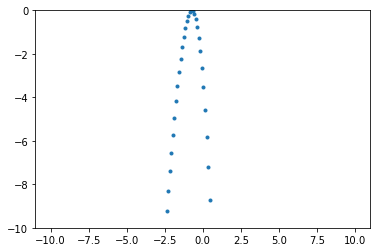

In [5]:
ts = np.linspace(-10, 10, 200)
theta2d = np.meshgrid(ts, ts, indexing = 'ij')
theta = np.stack([ti.ravel() for ti in theta2d], axis=-1)
theta1d = np.stack((theta2d[0][:,0], theta2d[0][:,0]),axis=-1)
theta1d[:,1] = theta1d[:,0]
theta = theta1d
sig_idx = 0
logjoint = calc_log_joint(theta, sig_idx)
logjoint -= logjoint.max()
levels = np.linspace(-10, 0, 21)
plt.plot(theta1d[:,0], logjoint, '.')
plt.ylim([-10, 0])
plt.show()

In [6]:
import berry
import inla
model = berry.Berry(sigma2_n = sigma2_n, n_arms=n_arms)

In [7]:
data = np.stack((y, n), axis=-1)
n_quad = 4
w_quad = 10
points, weights = np.polynomial.legendre.leggauss(n_quad)
etapts = w_quad * points
etawts = w_quad * weights
grid_eta = np.stack(np.meshgrid(*[etapts for k in range(n_arms)], indexing="ij"), axis=-1)
grid_eta_wts = np.prod(np.stack(np.meshgrid(*[etawts for k in range(n_arms)], indexing="ij"), axis=-1), axis=-1)

phat = (y/n)
sample_I = n * phat * (1 - phat)

sigma_precision = np.empty((sample_I.shape[0], *neg_precQ.shape))
sigma_precision[:] = neg_precQ[None, ...]
sigma_precision[..., arms, arms] += sample_I[:, None]
sigma_posterior = np.linalg.inv(sigma_precision)
w, v = np.linalg.eigh(sigma_posterior)

x0_info = inla.optimize_x0(model, data[:, None, :], sigma2_rule.pts[None, :, None])
mode = x0_info['x']

broadcast_shape = list(mode.shape)
for i in range(n_arms):
    broadcast_shape.insert(2, 1)
grid_theta = np.einsum('klij,...i,kli->kl...j', v, grid_eta, w) + mode.reshape(broadcast_shape)

# We need to multiply by the absolute value of the determinant of the
# transformation. Because we have already computed a eigendecomposition, the
# determinant of matrix is just product of eigenvalues.
det_jacobian = np.abs(w.prod(axis=-1))
grid_theta_wts = np.einsum('kl,...->kl...', det_jacobian, grid_eta_wts)

In [8]:
import quadrature
import fast_inla

fi = fast_inla.FastINLA(n_arms, sigma2_n=sigma2_n)
new_pts, new_wts = quadrature.build_grid(
    fi, y, n, integrate_sigma=False, n_theta=n_quad, w_theta=w_quad
)

/Users/tbent/.mambaforge/envs/kevlar/lib/python3.10/site-packages/jax/_src/lib/__init__.py:33: UserWarning: JAX on Mac ARM machines is experimental and minimally tested. Please see https://github.com/google/jax/issues/5501 in the event of problems.
  warnings.warn("JAX on Mac ARM machines is experimental and minimally tested. "


In [9]:
sigma_posterior[0,49:52]

array([[[-0.34381387,  0.3594243 ],
        [ 0.3594243 , -0.04404382]],

       [[10.91843766, -6.10205719],
        [-6.10205719,  3.66309609]],

       [[ 0.68495601, -0.2308111 ],
        [-0.2308111 ,  0.2945913 ]]])

In [10]:
w[0,49:52]

array([[-0.58335323,  0.19549554],
       [ 0.19181644, 14.38971731],
       [ 0.18749908,  0.79204822]])

In [11]:
v[0,49:52]

array([[[-0.8321324 , -0.55457703],
        [ 0.55457703, -0.8321324 ]],

       [[-0.49446178, -0.86919937],
        [-0.86919937,  0.49446178]],

       [[-0.4208847 , -0.90711414],
        [-0.90711414,  0.4208847 ]]])

5


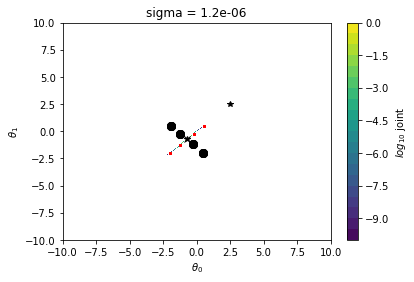

50


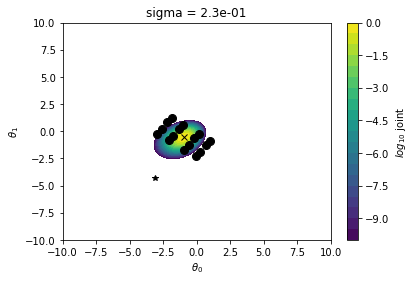

89


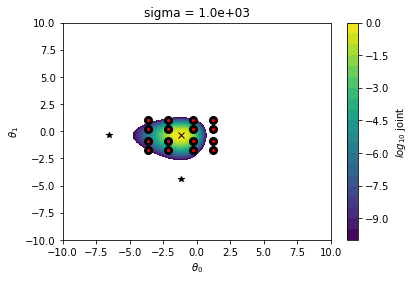

In [12]:
ts = np.linspace(-10, 10, 200)
theta2d = np.meshgrid(ts, ts, indexing = 'ij')
theta = np.stack([ti.ravel() for ti in theta2d], axis=-1)
for sig_idx in [5, 50, 89]:#range(0, sigma2_n, 1):
    print(sig_idx)
    logjoint = calc_log_joint(theta, sig_idx)

    levels = np.linspace(-10, 0, 21)
    plt.contourf(theta2d[0], theta2d[1], logjoint.reshape(theta2d[0].shape), levels=levels)
    plt.plot(*mode[0,sig_idx], 'kx')

    plt.plot(new_pts[0, :, :, sig_idx,0].ravel(), new_pts[0, :,:,sig_idx,1].ravel(), 'ko', markersize=8)
    plt.plot(grid_theta[0, sig_idx, :,:,0].ravel(), grid_theta[0, sig_idx, :,:,1].ravel(), 'ro', markersize=2)

    plt.plot(*(mode[0,sig_idx] + np.sqrt(np.abs(w[0,sig_idx,0])) * w_quad * v[0,sig_idx,0]), 'k*')
    plt.plot(*(mode[0,sig_idx] + np.sqrt(np.abs(w[0,sig_idx,1])) * w_quad * v[0,sig_idx,1]), 'k*')
    plt.xlabel(r'$\theta_0$')
    plt.ylabel(r'$\theta_1$')

    plt.title(f'sigma = {sigma2_rule.pts[sig_idx]:.1e}')
    cbar = plt.colorbar()
    cbar.set_label('$log_{10}$ joint')
    plt.xlim([ts.min(), ts.max()])
    plt.ylim([ts.min(), ts.max()])
    plt.show()

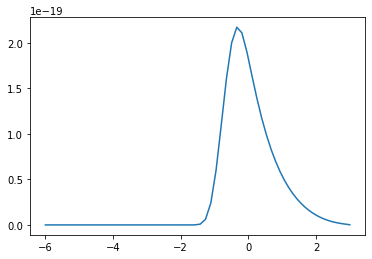

In [154]:
pr = new_pts[...,:2].reshape((-1, fi.sigma2_n, fi.n_arms))
log_joint = fi.log_joint(y, n, pr).reshape(new_pts.shape[:-1])
integral = (np.exp(log_joint) * new_wts).sum(axis=(1,2))
plt.plot(np.log10(fi.sigma2_rule.pts), integral[0] * fi.sigma2_rule.wts)
plt.show()